# The Picard-Lefschetz Thimble Propagator
### Teaching Notebook — from `Claude.py`

---

## Chapter 1: The Problem

### What are we computing?

We want the **quantum propagator** $K(x_f, T;\, x_i, 0)$ for a harmonic oscillator (a ball on a spring).

> $K$ answers: *what is the probability amplitude for a particle at position $x_i$ to arrive at $x_f$ after time $T$?*

### The Path Integral

Feynman's path integral says: **sum over every possible path** from $x_i$ to $x_f$, weighting each by a complex phase:

$$K(x_f, T;\, x_i, 0) = \int \mathcal{D}x(t)\; e^{iS[x]/\hbar}$$

where the **action** $S[x]$ for the harmonic oscillator is:

$$S[x] = \int_0^T \left[\frac{m}{2}\dot{x}^2 - \frac{m\omega^2}{2}x^2\right] dt$$

- $\frac{m}{2}\dot{x}^2$ = kinetic energy (how fast the particle moves)
- $\frac{m\omega^2}{2}x^2$ = potential energy (how stretched the spring is)

### Discretisation

We chop time $[0, T]$ into $N$ steps of size $\epsilon = T/N$. The path becomes $N+1$ positions: $x_0, x_1, \ldots, x_N$ with $x_0 = x_i$ and $x_N = x_f$ fixed. The $N-1$ interior points $x_1, \ldots, x_{N-1}$ are integrated over.

The discretised action is:

$$S = \sum_{k=0}^{N-1} \left[\frac{m}{2\epsilon}(x_{k+1} - x_k)^2 - \frac{\epsilon\, m\omega^2}{2}\, x_k^2\right]$$

and the propagator becomes a finite-dimensional integral:

$$K = \left(\frac{m}{2\pi i \hbar \epsilon}\right)^{N/2} \int dx_1 \cdots dx_{N-1}\; e^{iS/\hbar}$$

### The Sign Problem

On the real axis, $e^{iS/\hbar}$ is a **pure phase** — a unit-length arrow that spins wildly as we vary the path. Most arrows cancel each other out. This massive cancellation is called the **sign problem** and makes numerical integration extremely noisy.

### The Classical Path and Action

Among all paths, one is special: the **classical path** $x_{\text{cl}}(t)$ — the trajectory the particle would follow under Newton's laws. For the harmonic oscillator:

$$x_{\text{cl}}(t) = \frac{x_i \sin\omega(T-t) + x_f \sin\omega t}{\sin\omega T}$$

Its action (the **classical action**) is:

$$S_{\text{cl}} = \frac{m\omega}{2\sin\omega T}\left[(x_i^2 + x_f^2)\cos\omega T - 2 x_i x_f\right]$$

### The Hessian

Since the action is quadratic, any path can be written as $x = x_{\text{cl}} + \delta x$, and the action splits cleanly:

$$S[x] = S_{\text{cl}} + \frac{1}{2}\,\delta\mathbf{x}^T\, \mathbf{K}\, \delta\mathbf{x}$$

where $\mathbf{K}$ is the **(N-1) × (N-1) Hessian matrix** — the second derivative of the action with respect to the interior path positions. It is tridiagonal:

$$K_{jj} = \frac{2m}{\epsilon} - \epsilon\, m\omega^2, \qquad K_{j,j\pm 1} = -\frac{m}{\epsilon}$$

The Hessian measures the **curvature** of the action landscape around the classical path. Its eigenvalues $\{\lambda_n\}$ tell us how stiff each independent fluctuation mode is.

### The Exact Answer (our target)

For the harmonic oscillator, a closed-form exact propagator exists — the **Mehler kernel**:

$$K_{\text{exact}} = \sqrt{\frac{m\omega}{2\pi i \hbar \sin\omega T}} \;\exp\!\left[\frac{im\omega}{2\hbar\sin\omega T}\left((x_i^2+x_f^2)\cos\omega T - 2x_i x_f\right)\right]$$

This is our **answer key** — every numerical method must reproduce it.

---

## Chapter 2: The Thimble Propagator

### The Core Idea

The Picard-Lefschetz thimble is a **contour deformation** trick. Instead of integrating along the real axis (where $e^{iS}$ oscillates wildly), we **rotate each fluctuation mode 45° into the complex plane**.

This turns the oscillating integrand into a **damped Gaussian** — a smooth bell curve that can be evaluated analytically or sampled efficiently.

### Why does it work? — Mode by mode

Diagonalise the Hessian: $\mathbf{K} = V\, \text{diag}(\lambda_n)\, V^T$. In the eigenbasis, the action decouples into independent 1D integrals:

$$\int_{-\infty}^{\infty} d\xi_n\; \exp\!\left(\frac{i\lambda_n \xi_n^2}{2\hbar}\right)$$

Each integral has a **purely imaginary exponent** $\Rightarrow$ oscillates without damping.

**The thimble substitution:** for each mode, set $\xi_n = r_n\, t_n$ where $t_n$ is real and:

$$r_n = \begin{cases} e^{+i\pi/4} & \text{if } \lambda_n > 0 \\ e^{-i\pi/4} & \text{if } \lambda_n < 0 \end{cases}$$

Then the exponent becomes:

$$\frac{i\lambda_n (r_n t_n)^2}{2\hbar} = \frac{i\lambda_n (\pm i)\, t_n^2}{2\hbar} = \mp\frac{|\lambda_n|\, t_n^2}{2\hbar}$$

which is **real and negative** — a Gaussian that decays! The oscillation has been completely absorbed into the contour.

Each integral now evaluates to a standard Gaussian:

$$r_n \int_{-\infty}^{\infty} dt_n\; \exp\!\left(-\frac{|\lambda_n|\, t_n^2}{2\hbar}\right) = r_n\,\sqrt{\frac{2\pi\hbar}{|\lambda_n|}}$$

### Assembling the full propagator

The thimble propagator has three factors:

$$K_{\text{thimble}} = \underbrace{\left(\frac{m}{2\pi i\hbar\epsilon}\right)^{N/2}}_{\text{measure factor}} \;\times\; \underbrace{\prod_{n=1}^{N-1} r_n\,\sqrt{\frac{2\pi\hbar}{|\lambda_n|}}}_{\text{fluctuation integral}} \;\times\; \underbrace{e^{iS_{\text{cl}}/\hbar}}_{\text{classical phase}}$$

Working in log-space (to avoid numerical overflow):

**Fluctuation integral:**
$$\log|\text{fluct}| = \frac{1}{2}\sum_{n=1}^{N-1} \log\frac{2\pi\hbar}{|\lambda_n|}$$
$$\text{phase}_{\text{fluct}} = \frac{\pi}{4}\sum_{n=1}^{N-1} \text{sign}(\lambda_n)$$

**Measure factor:**
$$\log|\text{meas}| = \frac{N}{2}\left(\log m - \log(2\pi\hbar\epsilon)\right)$$
$$\text{phase}_{\text{meas}} = -\frac{N\pi}{4}$$

**Combined:**
$$K_{\text{thimble}} = \exp\!\Big(\log|\text{fluct}| + \log|\text{meas}| + i\big(\text{phase}_{\text{fluct}} + \text{phase}_{\text{meas}} + S_{\text{cl}}/\hbar\big)\Big)$$

---

## Chapter 3: The Code

Below is the **exact code** from `Claude.py` — the supporting functions and `thimble_propagator` itself.

In [2]:
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

### Supporting functions

These provide the exact answer, classical action, and Hessian that `thimble_propagator` depends on.

In [3]:
def exact_propagator(x_i, x_f, T, omega, m=1.0, hbar=1.0):
    """
    K(x_f, T; x_i, 0) = sqrt(m*w / (2*pi*i*hbar*sin(wT)))
        * exp(i*m*w / (2*hbar*sin(wT)) * [(xi^2+xf^2)*cos(wT) - 2*xi*xf])
    """
    swT = np.sin(omega * T)
    cwT = np.cos(omega * T)
    prefactor = np.sqrt(m * omega / (2 * np.pi * 1j * hbar * swT))
    phase = 1j * m * omega / (2 * hbar * swT) * (
        (x_i**2 + x_f**2) * cwT - 2 * x_i * x_f
    )
    return prefactor * np.exp(phase)


def classical_action(x_i, x_f, T, omega, m=1.0):
    """S_cl = m*w/(2*sin(wT)) * [(xi^2+xf^2)*cos(wT) - 2*xi*xf]"""
    swT = np.sin(omega * T)
    cwT = np.cos(omega * T)
    return m * omega / (2 * swT) * ((x_i**2 + x_f**2) * cwT - 2 * x_i * x_f)


def build_hessian(N, epsilon, omega, m=1.0):
    """
    (N-1)x(N-1) tridiagonal Hessian K_{jk} = d^2 S / d x_j d x_k
    for internal points x_1,...,x_{N-1}.

    Diagonal:     2m/eps - eps*m*w^2
    Off-diagonal: -m/eps
    """
    n = N - 1
    d = 2 * m / epsilon - epsilon * m * omega**2
    o = -m / epsilon
    K = np.diag(np.full(n, d))
    if n > 1:
        K += np.diag(np.full(n - 1, o), 1)
        K += np.diag(np.full(n - 1, o), -1)
    return K

### The Thimble Propagator

The star of the show — exact code from `Claude.py`.

In [4]:
def thimble_propagator(x_i, x_f, T, omega, N, m=1.0, hbar=1.0):
    """
    Evaluate propagator by deforming each eigenmode to its Lefschetz thimble.
    """
    epsilon = T / N
    S_cl = classical_action(x_i, x_f, T, omega, m)
    K = build_hessian(N, epsilon, omega, m)
    eigenvalues = np.linalg.eigvalsh(K)

    # Each mode contributes a Gaussian integral with width ~ 1/sqrt(|eigenvalue|)
    log_mag_fluct = 0.5 * np.sum(np.log(2 * np.pi * hbar / np.abs(eigenvalues)))
    # Each mode picks up a phase of +/-45 degrees from the rotation direction
    phase_fluct = np.sum(np.sign(eigenvalues)) * np.pi / 4

    # Normalisation factor from chopping continuous time into N discrete steps
    log_mag_meas = (N / 2) * (np.log(m) - np.log(2 * np.pi * hbar * epsilon))
    phase_meas = -N * np.pi / 4

    return np.exp((log_mag_fluct + log_mag_meas)
                  + 1j * (phase_fluct + phase_meas + S_cl / hbar))

### Line-by-line breakdown

| Line | What it computes | Formula |
|------|------------------|---------|
| `epsilon = T / N` | Time step size | $\epsilon = T/N$ |
| `S_cl = classical_action(...)` | Action of the classical (best) path | $S_{\text{cl}} = \frac{m\omega}{2\sin\omega T}[(x_i^2+x_f^2)\cos\omega T - 2x_i x_f]$ |
| `K = build_hessian(...)` | Curvature matrix of the action | Tridiagonal $(N{-}1)\times(N{-}1)$ matrix |
| `eigenvalues = eigvalsh(K)` | Stiffness of each independent wiggle mode | $\{\lambda_1, \ldots, \lambda_{N-1}\}$ |
| `log_mag_fluct` | Log-magnitude of the Gaussian product | $\frac{1}{2}\sum_n \log\frac{2\pi\hbar}{\|\lambda_n\|}$ |
| `phase_fluct` | Phase from the $\pm 45°$ rotations | $\frac{\pi}{4}\sum_n \text{sign}(\lambda_n)$ |
| `log_mag_meas` | Log-magnitude of the measure factor | $\frac{N}{2}[\log m - \log(2\pi\hbar\epsilon)]$ |
| `phase_meas` | Phase of the measure factor $(1/i)^{N/2}$ | $-N\pi/4$ |
| `return exp(...)` | Combine everything | $K = e^{\log|\cdot| + i(\text{phases} + S_{\text{cl}}/\hbar)}$ |

---

## Chapter 4: Diagrams — Why the Thimble Works

The plots below show the transformation for a single eigenmode. On the real axis the integrand oscillates (sign problem). On the thimble it becomes a smooth Gaussian (no cancellation).

In [5]:
m, hbar, omega, T = 1.0, 1.0, 2.0, 1.0
N_demo = 32
eps_demo = T / N_demo
K_demo = build_hessian(N_demo, eps_demo, omega, m)
evals_demo = np.linalg.eigvalsh(K_demo)

lam = evals_demo[0]
print(f"Lowest eigenvalue: lambda_1 = {lam:.4f}")
print(f"Sign: {'positive' if lam > 0 else 'negative'} => rotate {'+'  if lam > 0 else '-'}45 degrees")

Lowest eigenvalue: lambda_1 = 0.1832
Sign: positive => rotate +45 degrees


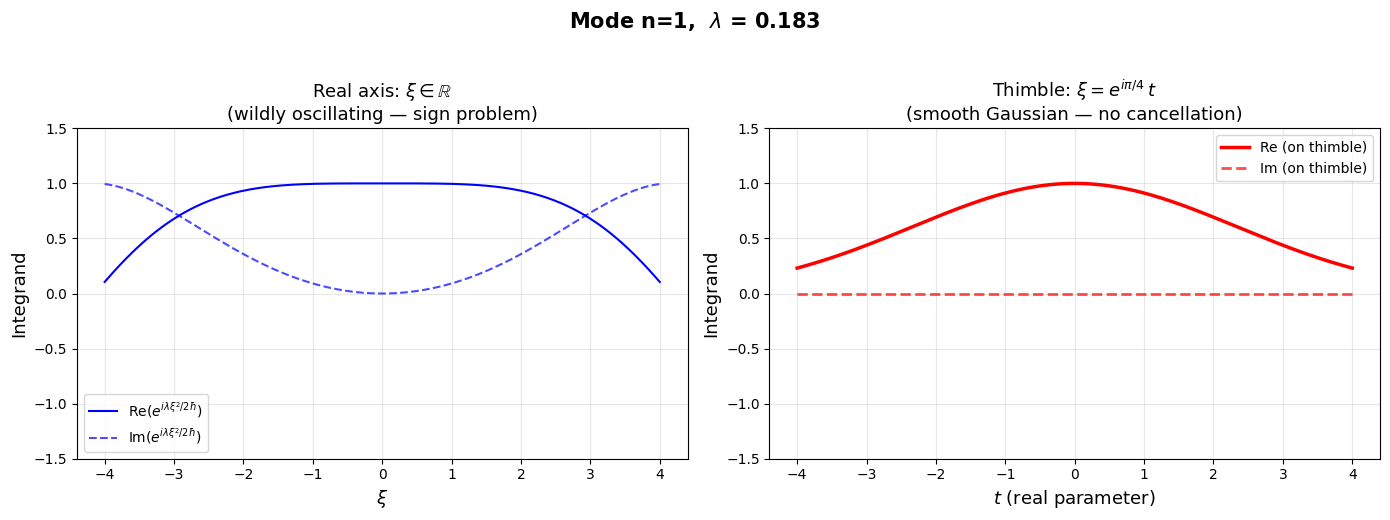

In [6]:
t_line = np.linspace(-4, 4, 500)

exp_real = np.exp(1j * lam * t_line**2 / (2 * hbar))

rot = np.exp(1j * np.pi / 4) if lam > 0 else np.exp(-1j * np.pi / 4)
xi_th = rot * t_line
exp_thimble = np.exp(1j * lam * xi_th**2 / (2 * hbar))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t_line, np.real(exp_real), 'b-', lw=1.5, label=r'Re$(e^{i\lambda\xi^2/2\hbar})$')
ax.plot(t_line, np.imag(exp_real), 'b--', lw=1.5, alpha=0.7, label=r'Im$(e^{i\lambda\xi^2/2\hbar})$')
ax.set_title(r'Real axis: $\xi \in \mathbb{R}$' + '\n(wildly oscillating — sign problem)', fontsize=13)
ax.set_xlabel(r'$\xi$', fontsize=13)
ax.set_ylabel('Integrand', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1.5, 1.5)

ax = axes[1]
ax.plot(t_line, np.real(exp_thimble), 'r-', lw=2.5, label=r'Re (on thimble)')
ax.plot(t_line, np.imag(exp_thimble), 'r--', lw=2, alpha=0.7, label=r'Im (on thimble)')
ax.set_title(r'Thimble: $\xi = e^{i\pi/4}\, t$' + '\n(smooth Gaussian — no cancellation)', fontsize=13)
ax.set_xlabel(r'$t$ (real parameter)', fontsize=13)
ax.set_ylabel('Integrand', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1.5, 1.5)

plt.suptitle(f'Mode n=1,  $\\lambda$ = {lam:.3f}', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### The Complex Plane View

This shows the landscape of $\text{Re}(iS/\hbar)$ in the complex $\xi$-plane. Red = large (diverging), blue = small (damped).

- The **blue line** (real axis) cuts across ridges and valleys — oscillation.
- The **red line** (thimble at 45°) follows the valley of steepest descent — pure damping.
- The **green dashed** contour is where $\text{Im}(iS/\hbar) = 0$ — constant phase (no oscillation).

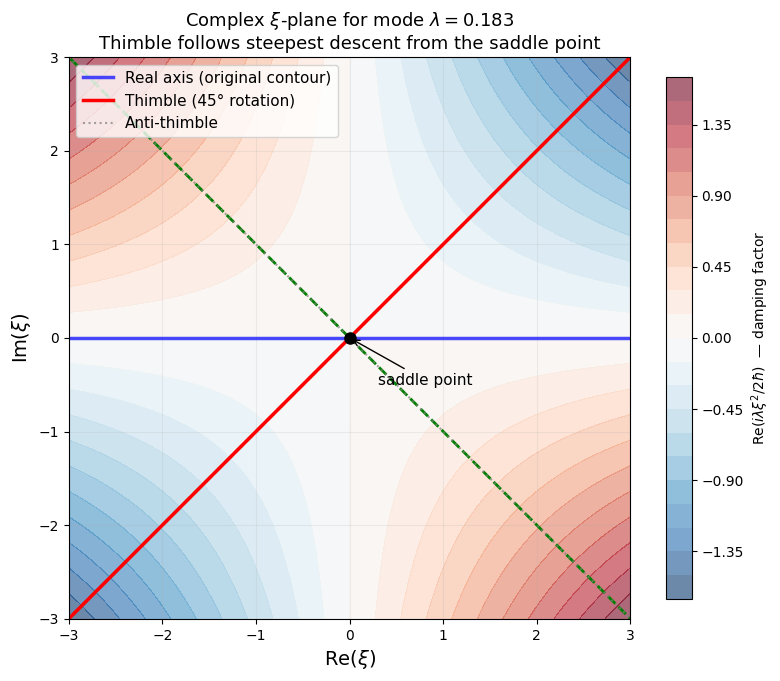

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))

re_g = np.linspace(-3, 3, 200)
im_g = np.linspace(-3, 3, 200)
RE, IM = np.meshgrid(re_g, im_g)
XI = RE + 1j * IM

EXP = 1j * lam * XI**2 / (2 * hbar)

cs = ax.contourf(RE, IM, np.real(EXP), levels=30, cmap='RdBu_r', alpha=0.6)
ax.contour(RE, IM, np.imag(EXP), levels=[0], colors='green',
           linewidths=2, linestyles='--')
plt.colorbar(cs, ax=ax, label=r'Re$(i\lambda\xi^2 / 2\hbar)$  — damping factor', shrink=0.85)

ax.plot([-3, 3], [0, 0], 'b-', lw=2.5, alpha=0.7, label='Real axis (original contour)')
ax.plot([-3, 3], [-3, 3], 'r-', lw=2.5, label=r'Thimble (45° rotation)')
ax.plot([-3, 3], [3, -3], 'gray', lw=1.5, ls=':', alpha=0.7, label='Anti-thimble')
ax.plot(0, 0, 'ko', markersize=8, zorder=5)
ax.annotate('saddle point', (0, 0), (0.3, -0.5), fontsize=11,
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(r'Re$(\xi)$', fontsize=14)
ax.set_ylabel(r'Im$(\xi)$', fontsize=14)
ax.set_title(f'Complex $\\xi$-plane for mode $\\lambda = {lam:.3f}$\n'
             f'Thimble follows steepest descent from the saddle point',
             fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Diagram: The Rotation for Each Mode

Every eigenmode gets independently rotated. The sign of $\lambda_n$ determines the rotation direction.

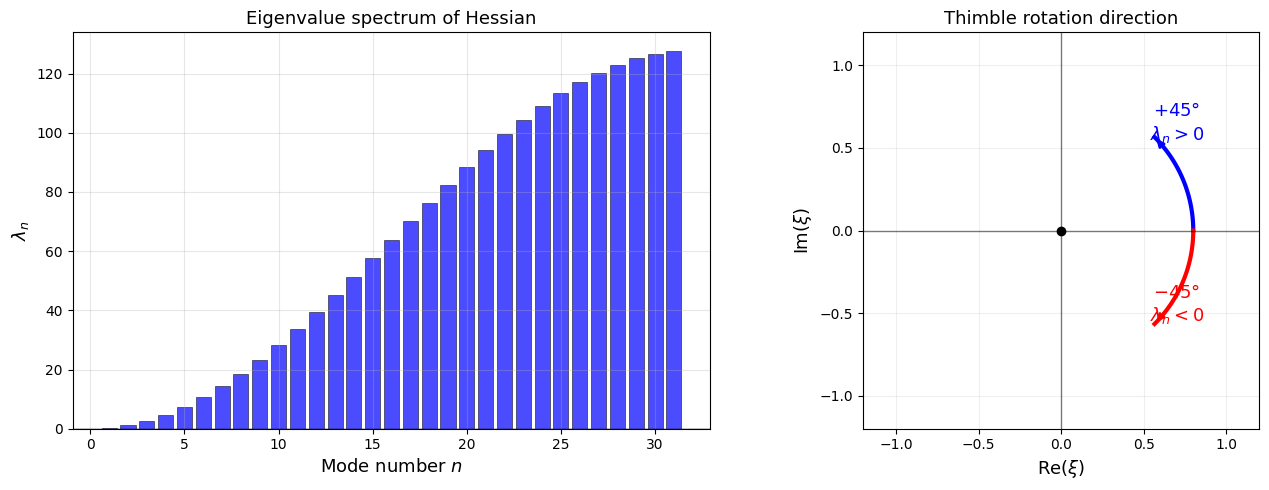

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
modes = np.arange(1, N_demo)
colors = ['red' if l < 0 else 'blue' for l in evals_demo]
ax.bar(modes, evals_demo, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Mode number $n$', fontsize=13)
ax.set_ylabel(r'$\lambda_n$', fontsize=13)
ax.set_title('Eigenvalue spectrum of Hessian', fontsize=13)
n_neg = np.sum(evals_demo < 0)
if n_neg > 0:
    ax.annotate(f'{n_neg} negative mode(s)\n(rotate $-45°$)',
                xy=(1, evals_demo[0]), fontsize=11,
                xytext=(8, evals_demo[0]),
                arrowprops=dict(arrowstyle='->', color='red'))
ax.grid(True, alpha=0.3)

ax = axes[1]
theta_pos = np.linspace(0, np.pi/4, 50)
theta_neg = np.linspace(0, -np.pi/4, 50)

r = 0.8
ax.plot(r*np.cos(theta_pos), r*np.sin(theta_pos), 'b-', lw=3)
ax.annotate('', xy=(r*np.cos(np.pi/4), r*np.sin(np.pi/4)),
            xytext=(r*np.cos(np.pi/4 - 0.15), r*np.sin(np.pi/4 - 0.15)),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(0.7, 0.55, r'$+45°$' + '\n' + r'$\lambda_n > 0$',
        fontsize=13, color='blue', ha='center')

ax.plot(r*np.cos(theta_neg), r*np.sin(theta_neg), 'r-', lw=3)
ax.annotate('', xy=(r*np.cos(-np.pi/4), r*np.sin(-np.pi/4)),
            xytext=(r*np.cos(-np.pi/4 + 0.15), r*np.sin(-np.pi/4 + 0.15)),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0.7, -0.55, r'$-45°$' + '\n' + r'$\lambda_n < 0$',
        fontsize=13, color='red', ha='center')

ax.plot([-1.2, 1.2], [0, 0], 'k-', lw=1, alpha=0.5)
ax.plot([0, 0], [-1.2, 1.2], 'k-', lw=1, alpha=0.5)
ax.plot(0, 0, 'ko', markersize=6)
ax.set_xlabel(r'Re$(\xi)$', fontsize=13)
ax.set_ylabel(r'Im$(\xi)$', fontsize=13)
ax.set_title('Thimble rotation direction', fontsize=13)
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---

## Chapter 5: The Final Propagator Result

We run `thimble_propagator` with the exact parameters from `Claude.py` and compare against the Mehler kernel.

In [9]:
m    = 1.0
hbar = 1.0
omega = 2.0
x_i  = 1.0
x_f  = 0.5
T    = 1.0
N    = 32

K_thimble = thimble_propagator(x_i, x_f, T, omega, N, m, hbar)
K_exact   = exact_propagator(x_i, x_f, T, omega, m, hbar)
S_cl      = classical_action(x_i, x_f, T, omega, m)

print("=" * 60)
print("  THIMBLE PROPAGATOR RESULT")
print("=" * 60)
print(f"\n  Parameters:  m={m}, hbar={hbar}, omega={omega}, T={T}")
print(f"  Boundary:    x_i={x_i}, x_f={x_f}")
print(f"  Time slices: N={N}")
print(f"\n  Classical action S_cl = {S_cl:.10f}")
print(f"\n  K_thimble = {K_thimble:.10f}")
print(f"  K_exact   = {K_exact:.10f}")
print(f"\n  |K_thimble| = {abs(K_thimble):.10f}")
print(f"  |K_exact|   = {abs(K_exact):.10f}")
print(f"\n  arg(K)/pi:    {np.angle(K_thimble)/np.pi:.10f}  (thimble)")
print(f"                {np.angle(K_exact)/np.pi:.10f}  (exact)")
print(f"\n  Relative error: {abs(K_thimble - K_exact)/abs(K_exact):.2e}")
print(f"\n  (Error is O(1/N^2) from discretisation,")
print(f"   not from the thimble method itself.)")

  THIMBLE PROPAGATOR RESULT

  Parameters:  m=1.0, hbar=1.0, omega=2.0, T=1.0
  Boundary:    x_i=1.0, x_f=0.5
  Time slices: N=32

  Classical action S_cl = -1.6718221132

  K_thimble = -0.4583496944-0.3739760873j
  K_exact   = -0.4584274860-0.3740395589j

  |K_thimble| = 0.5915594275
  |K_exact|   = 0.5916598276

  arg(K)/pi:    -0.7821575066  (thimble)
                -0.7821575066  (exact)

  Relative error: 1.70e-04

  (Error is O(1/N^2) from discretisation,
   not from the thimble method itself.)


### Convergence: error shrinks as $N$ grows

       N     |K_thimble|       arg(K)/pi     rel error
  ------  --------------  --------------  ------------
       4    0.5851356622   -0.7821575066      1.10e-02
       8    0.5900476949   -0.7821575066      2.72e-03
      16    0.5912579424   -0.7821575066      6.79e-04
      32    0.5915594275   -0.7821575066      1.70e-04
      64    0.5916347320   -0.7821575066      4.24e-05
     128    0.5916535539   -0.7821575066      1.06e-05
     256    0.5916582592   -0.7821575066      2.65e-06
     512    0.5916594355   -0.7821575066      6.63e-07


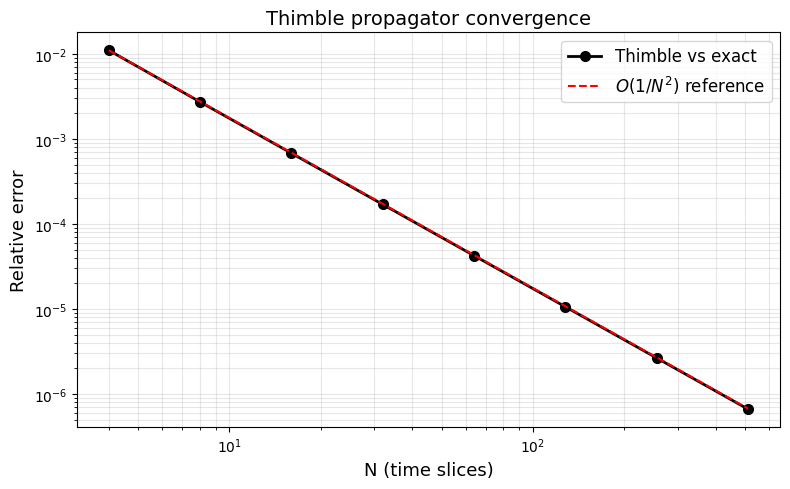

In [10]:
N_vals = [4, 8, 16, 32, 64, 128, 256, 512]
errors = []

print(f"  {'N':>6s}  {'|K_thimble|':>14s}  {'arg(K)/pi':>14s}  {'rel error':>12s}")
print(f"  {'-'*6}  {'-'*14}  {'-'*14}  {'-'*12}")

for Nv in N_vals:
    Kt = thimble_propagator(x_i, x_f, T, omega, Nv, m, hbar)
    err = abs(Kt - K_exact) / abs(K_exact)
    errors.append(err)
    print(f"  {Nv:6d}  {abs(Kt):14.10f}  {np.angle(Kt)/np.pi:14.10f}  {err:12.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
N_arr = np.array(N_vals, dtype=float)
ax.loglog(N_vals, errors, 'ko-', markersize=7, linewidth=2, label='Thimble vs exact')
ax.loglog(N_arr, errors[0] * (N_arr[0] / N_arr)**2, 'r--', linewidth=1.5, label=r'$O(1/N^2)$ reference')
ax.set_xlabel('N (time slices)', fontsize=13)
ax.set_ylabel('Relative error', fontsize=13)
ax.set_title('Thimble propagator convergence', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

---

## Summary

| Concept | Key Point |
|---------|----------|
| **Problem** | The path integral $\int e^{iS}$ oscillates wildly on the real axis (sign problem) |
| **Thimble idea** | Rotate each eigenmode 45° into the complex plane |
| **Result** | Oscillating phase $\to$ damped Gaussian. Same answer, zero cancellation |
| **Rotation rule** | $\lambda_n > 0 \Rightarrow +45°$, $\quad \lambda_n < 0 \Rightarrow -45°$ |
| **Each mode gives** | $r_n \sqrt{2\pi\hbar / |\lambda_n|}$ |
| **Why exact here** | The harmonic oscillator action is purely quadratic — Gaussian integration is exact |
| **Error source** | Only from discretisation: $O(1/N^2)$, not from the thimble method itself |